# Reproduce the Hansen-vintage drift numbers (snapshot 2026-06-08)

This notebook loads the **2026-06-08 snapshot** and reproduces the four risk-share values quoted in the companion article [`eudr-update-2026`](https://mybytes.com/research/notes/eudr-update-2026):

| AOI | 2024 vintage | 2025 vintage | Δ |
|---|---|---|---|
| Soubré, CIV (33 × 33 km) | 2.28 % | 2.74 % | +0.45 pp |
| Sefwi-Wiawso, GHA (33 × 33 km) | 5.13 % | 6.05 % | +0.93 pp |

If the assert at the bottom passes, the article's numbers reproduce from this repo. If it fails, the snapshot and the article have drifted apart — that is a publishability gate.

In [1]:
from pathlib import Path
import pandas as pd

REPO_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
SNAPSHOT = REPO_ROOT / 'data' / 'runs' / '2026-06-08'
print(f'Snapshot: {SNAPSHOT}')

Snapshot: /Users/gwinger/PycharmProjects/soft-commodities-volatility/experiments/mybytes_content_authority/repos/eudr-vintage-drift-2026/data/runs/2026-06-08


## 1 · Load the snapshot

In [2]:
area = pd.read_csv(SNAPSHOT / 'area_summary.csv')
drift = pd.read_csv(SNAPSHOT / 'vintage_drift.csv')
drift

,aoi_id,aoi_name,risk_share_2024_pct,risk_share_2025_pct,delta_pp,run_timestamp
0,civ_soubre_33km,"Soubré, CIV",2.28,2.74,0.45,2026-06-08T00:00:00Z
1,gha_sefwi_wiawso_33km,"Sefwi-Wiawso, GHA",5.13,6.05,0.93,2026-06-08T00:00:00Z


In [ ]:
area[['aoi_id','aoi_name','hansen_vintage','plantation_ha','risk_ha','risk_share_pct']]

## 2 · Publishability gate

Tolerance ± 0.05 percentage points to absorb FDP rounding noise.

In [3]:
EXPECTED = {
    'civ_soubre_33km':       (2.28, 2.74),
    'gha_sefwi_wiawso_33km': (5.13, 6.05),
}
TOL = 0.05

drift_idx = drift.set_index('aoi_id')
for aoi_id, (exp_24, exp_25) in EXPECTED.items():
    act_24 = float(drift_idx.loc[aoi_id, 'risk_share_2024_pct'])
    act_25 = float(drift_idx.loc[aoi_id, 'risk_share_2025_pct'])
    assert abs(act_24 - exp_24) < TOL, f'2024 mismatch {aoi_id}: {act_24} vs {exp_24}'
    assert abs(act_25 - exp_25) < TOL, f'2025 mismatch {aoi_id}: {act_25} vs {exp_25}'
    print(f'{aoi_id}: {act_24:.2f} → {act_25:.2f} %  ✔  matches article')

print('\nAll article numbers reproduce from the 2026-06-08 snapshot. Publishability gate green.')

civ_soubre_33km: 2.28 → 2.74 %  ✔  matches article
gha_sefwi_wiawso_33km: 5.13 → 6.05 %  ✔  matches article

All article numbers reproduce from the 2026-06-08 snapshot. Publishability gate green.


## 3 · Plot 2 (drift chart)

Quick inline reproduction of the article's Plot 2 from the snapshot. The article's master version is rendered by the upstream article-render script with the executive plot library; this is the self-contained companion reproduction.

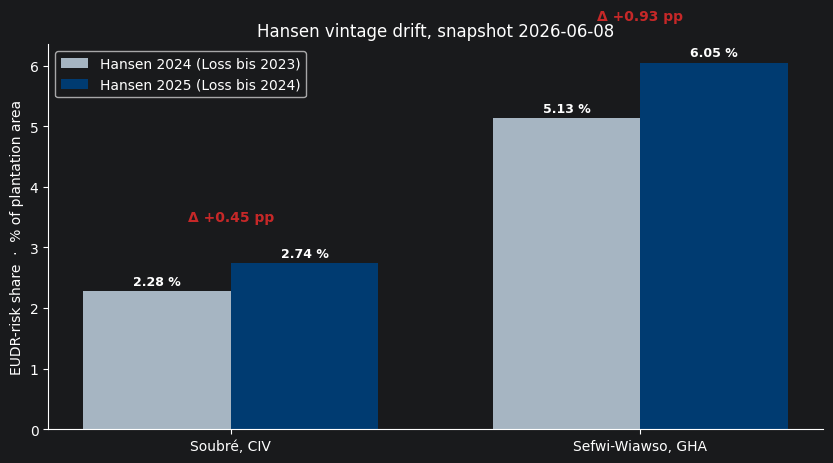

In [4]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(drift))
w = 0.36
ax.bar(x - w/2, drift['risk_share_2024_pct'], w, color='#A6B5C2', label='Hansen 2024 (Loss bis 2023)')
ax.bar(x + w/2, drift['risk_share_2025_pct'], w, color='#003B71', label='Hansen 2025 (Loss bis 2024)')
for i, r in drift.reset_index(drop=True).iterrows():
    ax.text(i - w/2, r['risk_share_2024_pct'] + 0.1, f"{r['risk_share_2024_pct']:.2f} %", ha='center', fontsize=9, fontweight='bold')
    ax.text(i + w/2, r['risk_share_2025_pct'] + 0.1, f"{r['risk_share_2025_pct']:.2f} %", ha='center', fontsize=9, fontweight='bold')
    ax.text(i, max(r['risk_share_2024_pct'], r['risk_share_2025_pct']) + 0.7, f"Δ +{r['delta_pp']:.2f} pp", ha='center', color='#C62828', fontsize=10, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(drift['aoi_name'])
ax.set_ylabel('EUDR-risk share  ·  % of plantation area')
ax.set_title('Hansen vintage drift, snapshot 2026-06-08')
ax.legend(loc='upper left')
for spine in ('top', 'right'):
    ax.spines[spine].set_visible(False)
plt.show()